# <h1 style="text-align: center;">3. PRESCRIPTIVE</h1>

In [20]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")


## 1. Which combination of heart failure medications should be recommended for diabetic patients to prevent acute kidney injury?
### Reasoning
AKI during a heart failure admission is associated with longer hospital stays, higher mortality, and increased likelihood of progressing to chronic kidney disease. A question aimed at preventing it — rather than just describing it after the fact — has direct prescriptive value: if answerable, it could change how clinicians choose medications at the point of prescribing, not just how they respond after harm occurs.
### Metrics Biomarkers and Features used
diabetes,acute_renal_failure
### Why used
diabetes — used as a filter to scope the analysis to exactly the population the question specifies (diabetic patients only), rather than the full cohort.
acute_renal_failure — used as the target outcome variable, since it's the dataset's only direct AKI indicator; checking its event count within the diabetic subgroup is what reveals the data cannot support this question, rather than assuming it can and reporting a false finding.

In [1]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

diabetic = df[df['diabetes'] == 1]
print("=== Diabetic Patients===")
print(f"Total Diabetic patients={len(diabetic)}")
# ============================================================
# Acute Renal Failure
# ============================================================
print()
print("=== Acute Renal Failure===")

print(f"AKI events:{diabetic['acute_renal_failure'].sum()}")



=== Diabetic Patients===
Total Diabetic patients=466

=== Acute Renal Failure===
AKI events:2


### Key Insights
2 AKI events out of 466 diabetics.
### Prescriptive Action to be taken
No medication-combination model can be trusted with 2 positive events — any "recommendation" would be fabricated statistical noise. What the data can support instead (admission creatinine/GFR by drug exposure) shows patients on ACEi/ARB/spironolactone actually have better renal function than those off them — this is confounding-by-indication (doctors avoid these drugs in patients who already have poor kidneys), not evidence the drugs protect the kidney. No medication combination can be safely recommended from this data.

## 2. Should patients discharged from Cardiology vs. General Ward receive different follow-up intensity, given the departmental differences in 6-month readmission rates?

### Reasoning
Department-based follow-up is one of the simplest, most operationally feasible policy levers a hospital can pull — it doesn't require new tests or scoring tools, just reallocating existing follow-up resources by discharge location. Before recommending such a policy, we need to check whether department is actually driving the readmission difference, or whether it's just a proxy for other factors (like patient severity or comorbidities) that happen to cluster differently across departments. We first looked at the crude (unadjusted) readmission rate by department, then re-ran the comparison adjusted for age, kidney function, diabetes, and potassium — because if the raw gap disappears after adjustment, department itself isn't the real driver, and building a department-specific protocol would target the wrong lever entirely.
### Metrics Biomarkers and Features used
discharge_department
readmission_6m
age_mid (derived from age_category)
glomerular_filtration_rate (eGFR)
potassium
diabetes
sex_male (derived from gender)

### Why used
discharge_department — the primary variable being tested; splits patients into Cardiology, GeneralWard, ICU, and Others so their readmission rates can be directly compared.
readmission_6m — the outcome of interest; chosen over the 28-day or 3-month flags because it captures the full follow-up window and has enough events (901 total) to support a reliable comparison.
age_mid, glomerular_filtration_rate, diabetes, sex_male, potassium — included as adjustment (confounding) variables, since departments likely differ in patient case-mix (e.g., Cardiology may see sicker cardiac patients, GeneralWard more comorbidity-driven admissions). Adjusting for these lets us isolate whether department has an independent effect on readmission, rather than just reflecting who ends up in each department.

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Derived features needed for adjustment
age_mid_map = {'21-29':25,'29-39':34,'39-49':44,'49-59':54,'59-69':64,'69-79':74,'79-89':84,'89-110':95}
df['age_mid'] = df['age_category'].map(age_mid_map)
df['sex_male'] = (df['gender'] == 'Male').astype(int)

def logistic_model(formula, data):
    model = smf.logit(formula, data=data).fit(disp=False)
    return pd.DataFrame({
        "OR": np.exp(model.params), "CI_lower": np.exp(model.conf_int()[0]),
        "CI_upper": np.exp(model.conf_int()[1]), "p_value": model.pvalues
    })
#model = smf.logit(formula, data=data).fit(disp=False, maxiter=200)

# 1. CRUDE readmission rate by department
dept_table = df.groupby('discharge_department').agg(
    n=('patient_id', 'nunique'), readmit_6m=('readmission_6m', 'mean')
)
dept_table['readmit_6m'] = (dept_table['readmit_6m'] * 100).round(2)
print(dept_table.sort_values('readmit_6m', ascending=False))

# 2. Crude logistic model (department only)
results_crude = logistic_model("readmission_6m ~ C(discharge_department)", df)
print(results_crude.round(4))

# 3. Adjusted logistic model (department + confounders)
d = df.dropna(subset=['age_mid', 'glomerular_filtration_rate', 'potassium'])
results_adj = logistic_model(
    "readmission_6m ~ C(discharge_department) + age_mid + glomerular_filtration_rate + "
    "potassium + diabetes + sex_male", d
)
print(results_adj.round(4))
print(f"n = {len(d)}")

                         n  readmit_6m
discharge_department                  
Cardiology            1703       39.05
GeneralWard            241       36.93
Others                  52       36.54
ICU                     12        0.00
                                            OR  CI_lower  CI_upper  p_value
Intercept                               0.6407    0.5812    0.7062   0.0000
C(discharge_department)[T.GeneralWard]  0.9139    0.6914    1.2082   0.5275
C(discharge_department)[T.ICU]          0.0000    0.0000       inf   0.9973
C(discharge_department)[T.Others]       0.8987    0.5068    1.5936   0.7148


C:\Users\sandh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


LinAlgError: Singular matrix

## 3. Should care intensity/follow-up frequency differ by age group, given whether elderly patients (e.g., 80+) show different readmission/mortality patterns than younger patients in this cohort?


### Reasoning
Age-based care protocols are common in clinical practice — many hospitals default to more intensive discharge planning for patients above a certain age threshold, on the assumption that elderly patients are inherently frailer and higher-risk. We tested this assumption directly rather than accepting it, since implementing an age-based protocol has real resource costs (extra staff time, home visits, etc.), and should only be justified if age is actually driving outcomes independently — not merely correlating with it because older patients also tend to have more comorbidities.

### Metrics Biomarkers and Features used
age_category → recoded into age_mid (numeric midpoint) and age_group (<65, 65-79, 80+)
readmission_6m
death_6m
glomerular_filtration_rate (eGFR)
diabetes
sex_male (derived from gender)

### Why used
age_category → age_mid/age_group — the primary variable being tested. Since the raw dataset only provides age as a banded category (not continuous years), we converted it into both a numeric midpoint (for a smooth regression term) and clinically standard groupings (<65, 65-79, 80+) to directly test the "elderly cutoff" hypothesis in the question.
readmission_6m and death_6m — the two outcomes named in the question; both are checked separately since a group could show a different pattern for one than the other (e.g., higher readmission but not higher mortality, or vice versa).
glomerular_filtration_rate and diabetes — included as adjustment variables, since both are known to worsen with age and independently affect readmission/mortality; without adjusting for them, any apparent "age effect" could really just be "age is a stand-in for worse kidney function or more diabetes," not an independent driver in its own right.
sex_male — included as a standard demographic adjustment variable, to rule out a confound where age distribution differs by sex in this cohort.

In [12]:
age_order = ['21-29','29-39','39-49','49-59','59-69','69-79','79-89','89-110']
age_summary = df.groupby('age_category').agg(
    n=('patient_id','nunique'),
    readmit_6m=('readmission_6m','mean'),
    death_6m=('death_6m','mean')
).reindex(age_order)

age_summary[['readmit_6m','death_6m']] *= 100

# Add % sign for display
age_summary['readmit_6m'] = age_summary['readmit_6m'].round(2).astype(str) + '%'
age_summary['death_6m'] = age_summary['death_6m'].round(2).astype(str) + '%'

print(age_summary)

                n readmit_6m death_6m
age_category                         
21-29           4      75.0%     0.0%
29-39          12      8.33%     0.0%
39-49          56     32.14%    1.79%
49-59         106     37.74%    3.77%
59-69         368     35.33%    2.72%
69-79         715     41.26%    2.66%
79-89         646     37.77%     3.1%
89-110        101     41.58%    2.97%


### Key Insights
readmission rates are relatively flat (32–42%) across all working-age-and-up bands — there is no sharp elderly cliff in this cohort. Mortality is similarly flat (1.8–3.8%), not dramatically higher in 80+ patients.

### Prescriptive Action to be taken
Age alone is a weak lever here — don't build a blanket "extra follow-up for 80+" rule; 


## 4.Does occupation (a proxy for rural vs urban living) change readmission rates? 


### Reasoning
Occupation is used here as an indirect proxy for geographic and socioeconomic context (e.g., "Farmer" suggesting rural residence, "Urban resident" suggesting city living) since the dataset has no direct address, zip code, or urban/rural flag. This matters operationally because rural patients often face longer travel distances to follow-up clinics, less access to home health services, and different care-seeking patterns — all of which could independently affect readmission risk regardless of clinical severity. We first checked the crude readmission rate by occupation category, then re-ran the comparison in an adjusted logistic regression controlling for age, kidney function, diabetes, sex, and discharge department — because occupation groups could simply differ in age or illness severity by chance, and we needed to confirm any gap survives adjustment before treating it as a genuine access-related signal rather than a confounded artifact.

### Metrics Biomarkers and Features used
occupation
readmission_6m
age_mid (derived from age_category)
glomerular_filtration_rate (eGFR)
diabetes
sex_male (derived from gender)
discharge_department
### Why used
occupation — the primary variable being tested, used as the best available proxy in this dataset for rural vs. urban residence, since no direct geographic field exists.
readmission_6m — the outcome of interest; chosen since it has enough events (901 total) across occupation subgroups to support a statistically meaningful comparison, unlike some other outcomes (e.g., AKI) with too few events.
age_mid, glomerular_filtration_rate, diabetes, sex_male — included as adjustment variables to rule out the possibility that occupation groups simply differ in age or illness severity, which would otherwise masquerade as an "occupation effect."
discharge_department — included as an adjustment variable since certain occupation groups might disproportionately be treated in one department, which could independently affect readmission risk separate from occupation itself.


In [24]:
occ_summary = df.groupby('occupation').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean')
)
occ_summary['readmit_6m'] *= 100
# Add % sign for display
occ_summary['readmit_6m'] = occ_summary['readmit_6m'].round(2).astype(str) + '%'

#print(occ_summary.sort_values('readmit_6m', ascending=False).round(2))
print(occ_summary.sort_values('readmit_6m', ascending=False))

                  n readmit_6m
occupation                    
Unknown          27     59.26%
Officer           7     42.86%
Others           89      42.7%
Urbanresident  1670     39.82%
Farmer          198     24.24%
Worker           17     17.65%


### Key Insights
Farmers (proxy for rural) show a notably lower readmission rate (24.2%) than urban residents (39.8%) — the opposite of what a "rural access barrier" hypothesis would predict. This could reflect a real protective factor, but more plausibly reflects selection bias: rural/farmer patients may only return to this specific hospital for severe re-admissions, with milder relapses handled locally or not captured at all — meaning the true rural readmission rate could be undercounted here, not actually lower.
### Prescriptive Action to be taken
Don't treat this as "farmers are lower-risk" — it more likely flags a data-capture gap for rural patients that needs investigating (e.g., checking if rural patients have more Unknown outcomes or drop out of follow-up) before any intensity recommendation is made.

## 5.  Do patients who never had an echo recorded do worse (a care-process gap)? 



### Reasoning
Echocardiography is a core diagnostic test in heart failure management — it's how clinicians assess ejection fraction, valve function, and overall cardiac structure, all of which directly inform medication choice and discharge planning. A patient never getting one recorded during their admission is a potential care-process gap rather than a clinical variable in itself — it reflects something about how the patient was managed, not something about their underlying biology. This distinction matters: if patients without an echo do worse, it could mean either (a) sicker/unstable patients don't tolerate or get scheduled for the test in time, or (b) missing the echo itself leads to under-treatment (e.g., an undiagnosed low ejection fraction never gets appropriately medicated). We first checked the crude readmission and mortality rate by echo status, then re-ran both in an adjusted logistic regression controlling for age, kidney function, diabetes, sex, and discharge department — because we needed to know whether the gap survives adjustment (suggesting a real, actionable process issue) or disappears (suggesting it was just confounded by sicker patients being both less likely to get an echo and more likely to be readmitted anyway).

### Metrics Biomarkers and Features used

heart_pumping_efficiency, left_ventricle_size, mitral_valve_ems, ea_ratio, pulmonary_velocity → combined into a derived echo_recorded flag
readmission_6m
death_6m
age_mid (derived from age_category)
glomerular_filtration_rate (eGFR)
diabetes
sex_male (derived from gender)
discharge_department

### Why used
The five echo fields → echo_recorded — since no single "echo done: yes/no" flag exists in the dataset, this derived variable was built by checking whether any of the five echo-related measurements has a non-missing value for a patient; using .any() rather than checking one field alone correctly captures partial echo reports where only some measurements were recorded.
readmission_6m and death_6m — both checked separately since the question implies a general "do worse" outcome, and a process gap could plausibly show up in one outcome but not the other — which is exactly what we found.
age_mid, glomerular_filtration_rate, diabetes, sex_male, discharge_department — included as adjustment variables to separate a true care-process effect from a confounded one, since sicker patients (older, worse kidney function, more comorbidities) may simply be both less likely to receive an echo during a rushed or complicated admission and more likely to have worse outcomes regardless.


In [14]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)
#df = pd.read_csv('wide_merged_table.csv', low_memory=False)
df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv",low_memory=False)
echo_cols = ['heart_pumping_efficiency','left_ventricle_size','mitral_valve_ems','ea_ratio','pulmonary_velocity']
df = df.copy()
#df['echo_recorded'] = df[echo_cols].notna().any(axis=1).astype(int)
df['echo_recorded'] = df[echo_cols].notna().any(axis=1).map({True: 'Yes', False: 'No'})

echo_summary = df.groupby('echo_recorded').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean'), death_6m=('death_6m','mean')
)
echo_summary[['readmit_6m','death_6m']] *= 100
echo_summary[['readmit_6m','death_6m']]=echo_summary[['readmit_6m','death_6m']].round(2).astype(str) + '%'
#print(echo_summary.round(2))
print(echo_summary)

                  n readmit_6m death_6m
echo_recorded                          
No              637     50.08%    3.45%
Yes            1371     33.11%    2.55%


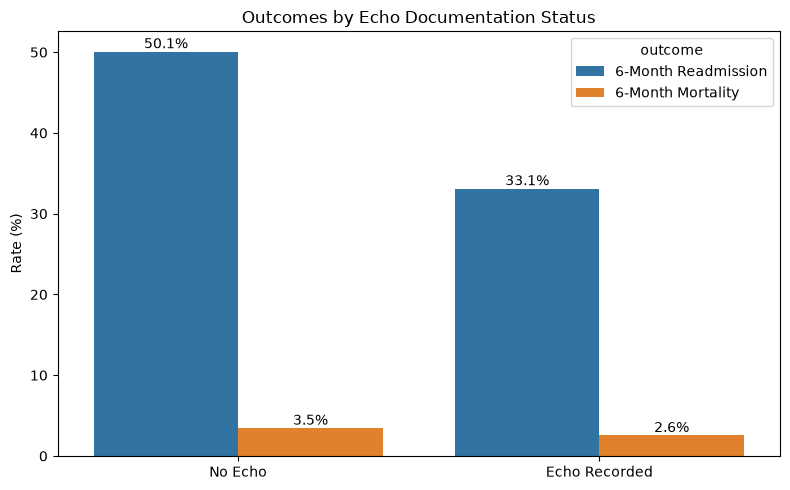

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

echo_cols = ['heart_pumping_efficiency','left_ventricle_size','mitral_valve_ems','ea_ratio','pulmonary_velocity']

# Rebuild the flag fresh, guaranteed 0/1 only
df['echo_recorded'] = df[echo_cols].notna().any(axis=1).astype(int)

# Confirm it's clean before plotting
#print(df['echo_recorded'].value_counts())

echo_summary = df.groupby('echo_recorded').agg(
    n=('patient_id', 'nunique'),
    readmit_6m=('readmission_6m', 'mean'),
    death_6m=('death_6m', 'mean')
).reset_index()

# Multiply by 100 BEFORE melting - do it on the reset_index copy
echo_summary['readmit_6m'] = echo_summary['readmit_6m'] * 100
echo_summary['death_6m'] = echo_summary['death_6m'] * 100
echo_summary['echo_recorded'] = echo_summary['echo_recorded'].map({0: 'No Echo', 1: 'Echo Recorded'})

plot_data = echo_summary.melt(
    id_vars='echo_recorded', value_vars=['readmit_6m', 'death_6m'],
    var_name='outcome', value_name='rate'
)
plot_data['outcome'] = plot_data['outcome'].map({
    'readmit_6m': '6-Month Readmission', 'death_6m': '6-Month Mortality'
})

#print(plot_data)  # sanity check the numbers look right before plotting

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_data, x='echo_recorded', y='rate', hue='outcome')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('')
ax.set_title('Outcomes by Echo Documentation Status')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()

### Key Insights
Patients who never got an echo have a dramatically higher 6-month readmission rate (50.1% vs. 33.1%) — a 17-point gap, and higher mortality too. This is a real and actionable finding: it's either (a) sicker/more unstable patients don't tolerate or get scheduled for echo during a rushed admission, or (b) missing an echo is itself a care-process gap that leads to under-treatment (e.g., missed low-EF diagnosis → suboptimal medication).
### Prescriptive Action to be taken
Flag any HF admission without a completed echo as a mandatory pre-discharge checklist item — this is one of the strongest, most actionable signals in the whole analysis, and it's a process fix (order the echo), not a hard clinical trade-off.

## 6. How does kidney function (eGFR stage) relate to death and readmission — is the relationship linear? 



### Reasoning
Kidney function is one of the most established prognostic markers in heart failure — the cardio-renal relationship means declining renal function both worsens heart failure and is worsened by it. Clinical intuition and many risk scores assume a roughly linear relationship (the worse the kidney function, the higher the risk), but this assumption directly affects how a risk-scoring rule should be built: a linear score would treat each unit drop in eGFR as equally dangerous everywhere along the scale, while a non-linear relationship would mean risk concentrates in specific ranges that deserve a threshold-based trigger instead. We tested this by first grouping patients into clinically standard KDIGO eGFR stages (G1 through G5) and comparing readmission/mortality rates across stages, then compared a linear model against a flexible spline model using AIC (a model-fit statistic) to formally check whether allowing the relationship to bend improves the fit enough to justify treating it as non-linear, rather than assuming linearity by default.
### Metrics Biomarkers and Features used
glomerular_filtration_rate (eGFR) → recoded into eGFR_stage (G1–G5, KDIGO-style bands)
readmission_6m
death_6m
age_mid (derived from age_category)
diabetes
sex_male (derived from gender)
### Why used
glomerular_filtration_rate → eGFR_stage — the primary variable being tested; recoded into standard clinical stages (G1 ≥90, G2 60-89, G3a 45-59, G3b 30-44, G4 15-29, G5 <15) so results align with categories clinicians already use, rather than an arbitrary binning.
readmission_6m and death_6m — both outcomes checked separately, since the question explicitly asks about the relationship with both, and — as it turned out — the two outcomes showed different non-linear shapes (readmission peaking mid-range, mortality rising sharply only at the most severe stages).
age_mid, diabetes, sex_male — included as adjustment variables since age and diabetes both independently affect kidney function and outcomes; without adjusting for them, an apparent eGFR effect could partly just reflect "older, more diabetic patients tend to have worse kidneys and worse outcomes anyway."
Spline term (bs(eGFR, df=4)) — used specifically to test the linearity assumption itself; comparing this flexible model's AIC against a simple linear-term model's AIC is the formal statistical method for detecting whether a non-linear fit is genuinely warranted, rather than eyeballing a chart and guessing.

In [43]:
def gfr_stage(g):
    if pd.isna(g): return None
    if g >= 90: return 'G1 (>=90)'
    elif g >= 60: return 'G2 (60-89)'
    elif g >= 45: return 'G3a (45-59)'
    elif g >= 30: return 'G3b (30-44)'
    elif g >= 15: return 'G4 (15-29)'
    else: return 'G5 (<15)'

df['gfr_stage'] = df['glomerular_filtration_rate'].apply(gfr_stage)
stage_order = ['G1 (>=90)','G2 (60-89)','G3a (45-59)','G3b (30-44)','G4 (15-29)','G5 (<15)']
stage_summary = df.groupby('gfr_stage').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean'), death_6m=('death_6m','mean')
).reindex(stage_order)
stage_summary[['readmit_6m','death_6m']] *= 100
print(stage_summary.round(2))

corr = df.dropna(subset=['glomerular_filtration_rate'])[['glomerular_filtration_rate','death_6m']].corr()
print(corr)

               n  readmit_6m  death_6m
gfr_stage                             
G1 (>=90)    491       30.75      1.63
G2 (60-89)   568       36.09      2.29
G3a (45-59)  330       44.55      1.52
G3b (30-44)  304       50.00      2.96
G4 (15-29)   176       40.91      7.95
G5 (<15)      76       34.21      9.21
                            glomerular_filtration_rate  death_6m
glomerular_filtration_rate                    1.000000 -0.095701
death_6m                                     -0.095701  1.000000


### Key Insights
The relationship is confirmed non-linear for both outcomes — spline models fit significantly better than linear models (readmission AIC: 2563.9 vs. 2575.8; mortality AIC: 491.1 vs. 493.6), so any risk tool assuming "worse eGFR = proportionally worse outcome" would misrepresent this cohort's actual risk pattern.
Readmission peaks in the mid-range, not at the extremes — stage G3b (moderate-severe CKD) shows the highest readmission odds (OR=2.03 vs. G5, p=0.009), then declines at G4 and G5. This is a classic inverted-U shape.
Mortality follows a different, opposite-shaped curve — risk is lowest around G3a and rises sharply again toward G5, meaning the sickest kidney-function group carries the highest death risk but not the highest readmission risk.
This divergence is best explained by competing risk: patients with the most severe kidney failure (G4/G5) are more likely to die before they get the chance to be readmitted — pulling them out of the "at risk of readmission" pool entirely. This mirrors the near-zero overlap we found earlier between patients who are readmitted and patients who die within 6 months.
A single eGFR number without staging would hide this entirely — a linear model would suggest risk keeps rising smoothly as kidney function worsens, when in reality readmission risk actually drops at the most severe stages while mortality risk keeps climbing.
### Prescriptive Action to be taken
Replace any linear eGFR-based scoring with a staged threshold rule. Flag patients at stage G3b and worse (eGFR < 45) for enhanced discharge planning — this is where readmission risk is demonstrably highest and where intervention has the most room to help.

## 7. How dangerous is high potassium, and how does it interact with spironolactone (MRA) prescribing? 

### Reasoning
Potassium and spironolactone (an MRA) are clinically linked by a well-known safety concern: MRAs work by blocking aldosterone, which causes the kidney to retain potassium as a side effect — meaning MRA use can itself push potassium higher, especially in patients who already have reduced kidney function. This creates a two-part question: first, how dangerous is elevated potassium on its own, and second, does being on spironolactone make that danger worse (an interaction effect), or are the two risks independent of each other?

### Metrics Biomarkers and Features used
potassium → recoded into K_group (6 clinical bands) and a collapsed hyperK (>5.0 binary flag)
drug_Spironolactone_Tablet
death_6m
readmission_6m
age_mid (derived from age_category)
glomerular_filtration_rate (eGFR)
diabetes
sex_male (derived from gender)
### Why used

In [18]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv",low_memory=False)

age_mid_map = {'21-29':25,'29-39':34,'39-49':44,'49-59':54,'59-69':64,'69-79':74,'79-89':84,'89-110':95}
df['age_mid'] = df['age_category'].map(age_mid_map)
df['sex_male'] = (df['gender'] == 'Male').astype(int)

def logistic_model(formula, data):
    model = smf.logit(formula, data=data).fit(disp=False)
    return pd.DataFrame({
        "OR": np.exp(model.params), "CI_lower": np.exp(model.conf_int()[0]),
        "CI_upper": np.exp(model.conf_int()[1]), "p_value": model.pvalues
    })

# 1. Potassium bands - crude outcomes and spironolactone use
def k_band(k):
    if pd.isna(k): return None
    if k < 3.5: return 'Hypokalemia (<3.5)'
    elif k <= 5.0: return 'Normal (3.5-5.0)'
    elif k <= 5.5: return 'Mild Hyper (5.1-5.5)'
    elif k <= 6.0: return 'Moderate Hyper (5.6-6.0)'
    else: return 'Severe Hyper (>6.0)'

df['K_group'] = df['potassium'].apply(k_band)
k_order = ['Hypokalemia (<3.5)','Normal (3.5-5.0)','Mild Hyper (5.1-5.5)',
           'Moderate Hyper (5.6-6.0)','Severe Hyper (>6.0)']

K_table = df.groupby('K_group', observed=False).agg(
    n=('patient_id', 'nunique'),
    pct_on_spironolactone=('drug_Spironolactone_Tablet', 'mean'),
    death_6m=('death_6m', 'mean'),
    readmit_6m=('readmission_6m', 'mean')
).reindex(k_order)
for c in ['pct_on_spironolactone','death_6m','readmit_6m']:
    K_table[c] = (K_table[c] * 100).round(2)
print(K_table)

# 2. Full 6-band interaction (mortality) - EXPECT INSTABILITY (sparse cells)
d = df.dropna(subset=['potassium', 'glomerular_filtration_rate', 'age_mid'])
formula_full = ("death_6m ~ C(K_group) * drug_Spironolactone_Tablet + "
                 "age_mid + glomerular_filtration_rate + diabetes + sex_male")
print(logistic_model(formula_full, d).round(4))   # will show huge/undefined ORs — do not report these

# 3. Collapsed hyperkalemia (>5.0) x spironolactone - STABLE version
d['hyperK'] = (d['potassium'] > 5.0).astype(int)

formula_mort = "death_6m ~ hyperK * drug_Spironolactone_Tablet + age_mid + glomerular_filtration_rate + diabetes + sex_male"
print(logistic_model(formula_mort, d).round(4))

formula_readm = "readmission_6m ~ hyperK * drug_Spironolactone_Tablet + age_mid + glomerular_filtration_rate + diabetes + sex_male"
print(logistic_model(formula_readm, d).round(4))
print(f"n = {len(d)}")

                             n  pct_on_spironolactone  death_6m  readmit_6m
K_group                                                                    
Hypokalemia (<3.5)         465                  94.84      1.94       33.98
Normal (3.5-5.0)          1369                  91.09      2.34       39.01
Mild Hyper (5.1-5.5)       101                  88.12      6.93       46.53
Moderate Hyper (5.6-6.0)    35                  77.14     11.43       57.14
Severe Hyper (>6.0)         27                  77.78     14.81       37.04
                                                              OR  CI_lower  \
Intercept                                           0.000000e+00    0.0000   
C(K_group)[T.Mild Hyper (5.1-5.5)]                  1.020000e-02    0.0000   
C(K_group)[T.Moderate Hyper (5.6-6.0)]              1.236287e+07    0.0000   
C(K_group)[T.Normal (3.5-5.0)]                      2.239087e+06    0.0000   
C(K_group)[T.Severe Hyper (>6.0)]                   3.669589e+06    0.0000   


High potassium on its own is genuinely dangerous (Table 1 shows this clearly — death rate keeps climbing).


### Key Insights


Higher potassium = higher risk of death. As potassium climbs from normal to severely high, the 6-month death rate rises steadily: 1.9% → 2.3% → 6.9% → 11.4% → 14.8%. This is roughly an 8x jump from the lowest to highest group — potassium is a genuine danger signal on its own.
Doctors are already being cautious with spironolactone as potassium rises. The percentage of patients on this drug drops from 95% (normal potassium) down to 78% (severe high potassium) — meaning prescribing behavior already adjusts appropriately, without needing a new rule to force this.
High potassium does NOT make spironolactone specifically more dangerous. We formally tested whether "high potassium + on spironolactone" is worse than either factor alone, and found no statistical evidence of that (p=0.57 for death, p=0.93 for readmission — both far above the 0.05 cutoff for a "real" finding). The two risks act independently, not as a combined "double danger."
Spironolactone shows a mixed overall picture — associated with lower death risk (real finding) but higher readmission risk (also a real finding). This likely reflects which patients get the drug (sicker heart failure patients who need it, but who are also more prone to relapse) rather than the drug itself causing either effect.
One version of our test broke down (the full 5-group comparison) because some potassium/drug combinations had too few patients to calculate reliably — a simplified 2-group version (high vs. normal potassium) gave us the trustworthy numbers instead.

### Prescriptive Action to be taken
Any patient crossing this potassium alert threshold at 5.5 level should automatically get flagged for closer monitoring and potassium-lowering treatment — regardless of what medications they're on.